# Challenge 1 — Solar Yield Prediction

**Goal:** Train an XGBoost regressor to predict monthly average solar energy yield (PVOUT, kWh/kWp/day) for Australian cities using daily weather observations, then save the artifacts for use by a LangChain ReAct agent.

## Pipeline Overview
```
Global Solar Atlas Monthly TIFFs      Kaggle Weather Data (AUS)
                ↓                                ↓
        Rasterio extraction         Train/holdout split (2009/2010)
 Monthly PVOUT per city (target)    Aggregate to per city per month
                             ↓        ↓
                         XGBoost Regressor
                  (Optuna hyperparameter tuning)
                                  ↓
                            Saved artifacts
          (xgb_model, encoders, feature_cols, holdout_weather)
```

**Key decisions:**
- 2009/2010 chosen for best `Sunshine` coverage (~30 cities, 36–37% missing)
- Monthly PVOUT used as target — captures seasonal variation vs yearly average
- `Location`, `Date`, `Month`, `DayOfYear` excluded from features
- Honest R² reflects weather-driven signal only — no date-based shortcuts

## 1. Setup & Data Loading

Load the raw `weatherAUS.csv` (145,460 rows, 2007–2017, 49 Australian cities). Add a `Year` column for downstream splitting.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/raw")
WEATHER_CSV = DATA_DIR / "weatherAUS.csv"
SOLAR_DIR = (
    DATA_DIR / "Australia_GISdata_LTAy_AvgDailyTotals_GlobalSolarAtlas-v2_GEOTIFF"
)

df_all = pd.read_csv(WEATHER_CSV, parse_dates=["Date"])
df_all["Year"] = df_all["Date"].dt.year

print(
    f"Total rows: {len(df_all)} | Date range: {df_all['Date'].min().date()} to {df_all['Date'].max().date()}"
)

Total rows: 145460 | Date range: 2007-11-01 to 2017-06-25


## 2. Exploratory Data Analysis

Identify missing-value patterns across the full dataset and examine `Sunshine` coverage by year — the most important feature and the primary driver of year selection for training.

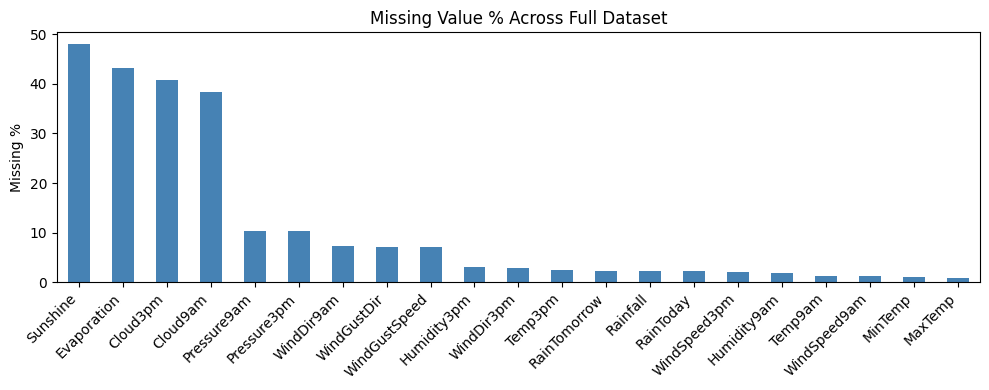

In [13]:
missing_pct = df_all.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

missing_pct.plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.title("Missing Value % Across Full Dataset")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

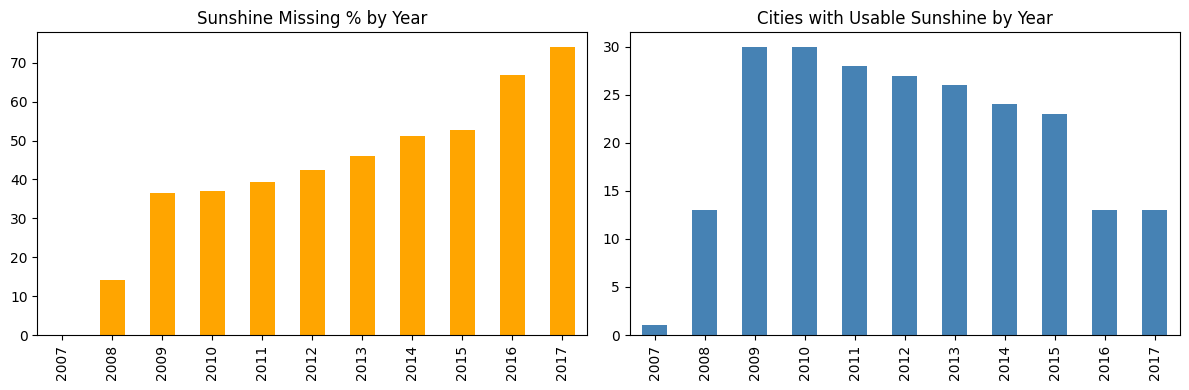

      missing_pct  cities_with_sunshine
Year                                   
2007          0.0                     1
2008         14.2                    13
2009         36.6                    30
2010         37.1                    30
2011         39.3                    28
2012         42.4                    27
2013         46.1                    26
2014         51.2                    24
2015         52.8                    23
2016         66.9                    13
2017         74.1                    13


In [14]:
sunshine_missing = (
    df_all.groupby("Year")["Sunshine"].apply(lambda x: x.isnull().mean() * 100).round(1)
)
cities_with_sunshine = df_all.groupby("Year").apply(
    lambda x: x.groupby("Location")["Sunshine"]
    .apply(lambda s: s.isnull().mean() < 0.5)
    .sum()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sunshine_missing.plot(
    kind="bar", ax=axes[0], color="orange", title="Sunshine Missing % by Year"
)
cities_with_sunshine.plot(
    kind="bar",
    ax=axes[1],
    color="steelblue",
    title="Cities with Usable Sunshine by Year",
)
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

print(
    pd.DataFrame(
        {"missing_pct": sunshine_missing, "cities_with_sunshine": cities_with_sunshine}
    )
)

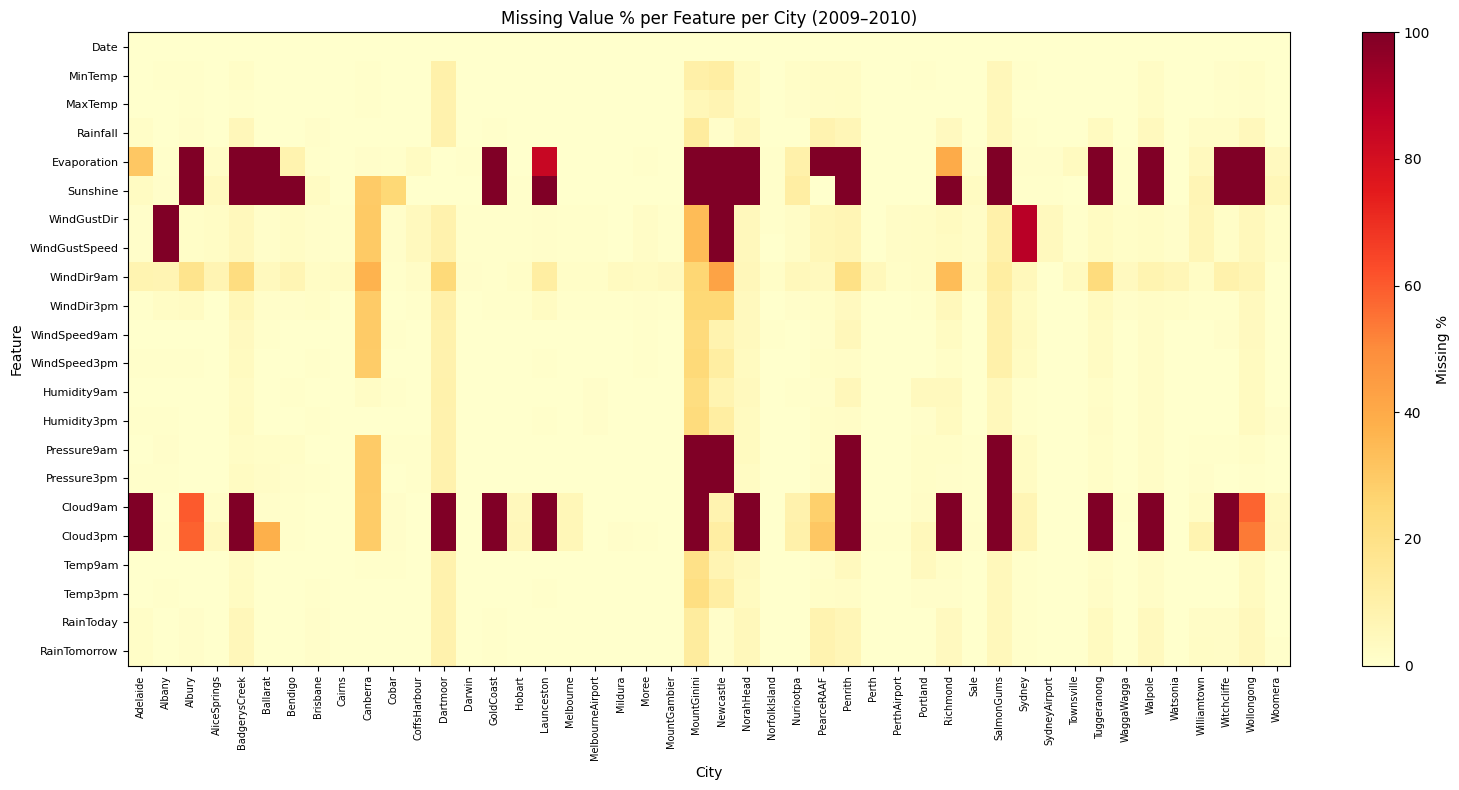

In [62]:
missing_by_city = (
    df_all[df_all["Year"].isin([2009, 2010])]
    .groupby("Location")
    .apply(lambda x: x.isnull().mean() * 100)
    .drop(columns=["Location", "Year"], errors="ignore")
    .T
)

fig, ax = plt.subplots(figsize=(16, 8))

im = ax.imshow(missing_by_city.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=100)

ax.set_xticks(range(len(missing_by_city.columns)))
ax.set_yticks(range(len(missing_by_city.index)))
ax.set_xticklabels(missing_by_city.columns, rotation=90, fontsize=7)
ax.set_yticklabels(missing_by_city.index, fontsize=8)

plt.colorbar(im, ax=ax, label="Missing %")
ax.set_title("Missing Value % per Feature per City (2009–2010)")
ax.set_xlabel("City")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 3. Train / Holdout Split

**2009 → train**, **2010 → holdout** — best `Sunshine` coverage among all years. `Date` is retained here for monthly PVOUT lookup in Section 5 and dropped before training.

In [15]:
TRAIN_YEAR = 2009
HOLDOUT_YEAR = 2010

df_train = (
    df_all[df_all["Year"] == TRAIN_YEAR].copy().drop(columns=["Year", "RainTomorrow"])
)
df_holdout = (
    df_all[df_all["Year"] == HOLDOUT_YEAR].copy().drop(columns=["Year", "RainTomorrow"])
)

df_holdout_raw = df_holdout.copy()

print(f"Train   : {df_train.shape}  | cities: {df_train['Location'].nunique()}")
print(f"Holdout : {df_holdout.shape} | cities: {df_holdout['Location'].nunique()}")

Train   : (16789, 22)  | cities: 46
Holdout : (16782, 22) | cities: 46


## 4. PVOUT Extraction from Global Solar Atlas

Geocode each city with `geopy` (Nominatim), then extract PVOUT values from the Global Solar Atlas rasters using `rasterio`. Each city's bounding box from Nominatim is used to average all raster pixels within the city's geographic extent.

- **Yearly PVOUT** — for visualization only
- **Monthly PVOUT** — regression target, captures seasonal solar variation
- 44/46 cities resolved (NorfolkIsland outside raster bounds, MountGinini bbox too small)

In [5]:
from geopy.geocoders import Nominatim
import re
import time

geolocator = Nominatim(user_agent="solar_assessment")


def normalize_city(city: str) -> str:
    return re.sub(r"([a-z])([A-Z])", r"\1 \2", city)


cities = df_train["Location"].unique()

city_locations = {}
for city in cities:
    for query in [f"{normalize_city(city)}, Australia", f"{city}, Australia"]:
        try:
            location = geolocator.geocode(query)
            time.sleep(1)
            if location:
                city_locations[city] = location
                break
        except Exception:
            pass

city_coords = {
    city: (loc.latitude, loc.longitude) for city, loc in city_locations.items()
}

failed = [c for c in cities if c not in city_locations]
print(f"Geocoded : {len(city_locations)}/{len(cities)}")
if failed:
    print(f"Failed   : {failed}")

Geocoded : 46/46


In [6]:
from rasterio.mask import mask
from shapely.geometry import box
import rasterio


MONTHLY_PVOUT_DIR = SOLAR_DIR / "monthly"


def extract_pvout_bbox(location_raw: dict, src) -> tuple[float | None, object]:
    """Average PVOUT within the city's Nominatim bounding box."""
    south, north, west, east = [float(x) for x in location_raw["boundingbox"]]
    bbox_geom = box(west, south, east, north)
    try:
        out_image, _ = mask(src, [bbox_geom], crop=True, nodata=src.nodata)
        values = out_image[0].astype(float)
        values[values == src.nodata] = np.nan
        valid = values[~np.isnan(values)]
        return float(valid.mean()) if len(valid) > 0 else None, bbox_geom
    except Exception:
        return None, bbox_geom


city_pvout_monthly = {city: {} for city in city_locations}
city_bboxes = {}

for month in range(1, 13):
    with rasterio.open(MONTHLY_PVOUT_DIR / f"PVOUT_{month:02d}.tif") as src:
        for city, loc in city_locations.items():
            pvout, geom = extract_pvout_bbox(loc.raw, src)
            city_pvout_monthly[city][month] = pvout
            if city not in city_bboxes:
                city_bboxes[city] = geom

extracted = sum(
    1 for m in city_pvout_monthly.values() if any(v is not None for v in m.values())
)
print(f"Monthly PVOUT extracted : {extracted}/{len(city_locations)} cities × 12 months")

Monthly PVOUT extracted : 44/46 cities × 12 months


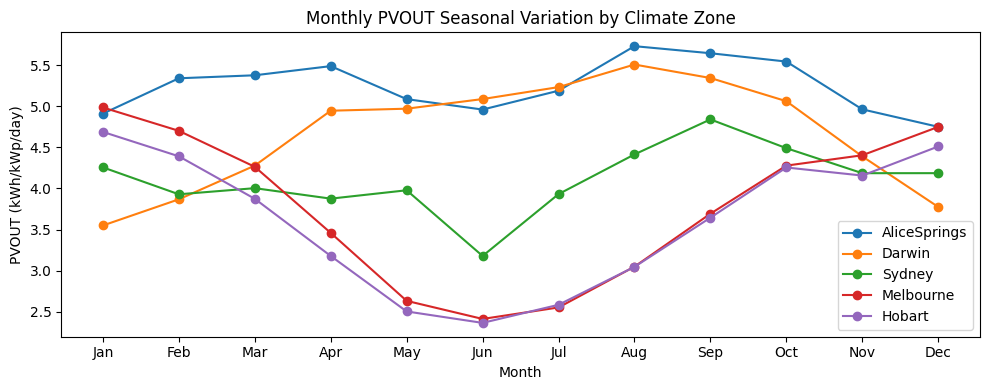

In [7]:
# Seasonal variation — sample cities across climate zones
sample_cities = ["AliceSprings", "Darwin", "Sydney", "Melbourne", "Hobart"]
month_labels = [pd.Timestamp(2010, m, 1).strftime("%b") for m in range(1, 13)]

plt.figure(figsize=(10, 4))
for city in sample_cities:
    if city in city_pvout_monthly:
        vals = [city_pvout_monthly[city].get(m) for m in range(1, 13)]
        plt.plot(range(1, 13), vals, marker="o", label=city)
plt.title("Monthly PVOUT Seasonal Variation by Climate Zone")
plt.xlabel("Month")
plt.ylabel("PVOUT (kWh/kWp/day)")
plt.xticks(range(1, 13), month_labels)
plt.legend()
plt.tight_layout()
plt.show()

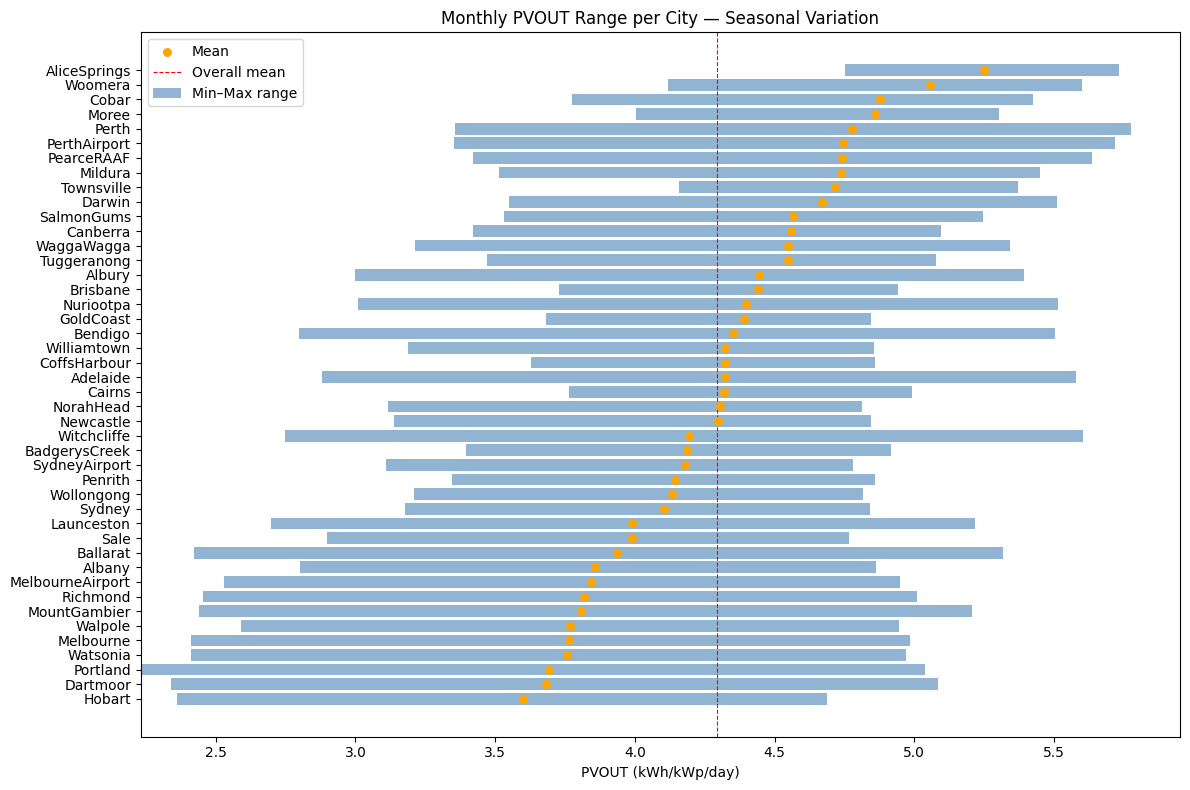

In [39]:
# Monthly PVOUT range per city — min, max, mean
pvout_stats = {
    city: {
        "min": min(months.values()),
        "max": max(months.values()),
        "mean": sum(months.values()) / len(months.values()),
    }
    for city, months in city_pvout_monthly.items()
    if all(v is not None for v in months.values())
}

pvout_df = pd.DataFrame(pvout_stats).T.sort_values("mean", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(
    pvout_df.index,
    pvout_df["max"] - pvout_df["min"],
    left=pvout_df["min"],
    color="steelblue",
    alpha=0.6,
    label="Min–Max range",
)
ax.scatter(
    pvout_df["mean"], pvout_df.index, color="orange", zorder=5, s=30, label="Mean"
)
ax.axvline(
    pvout_df["mean"].mean(),
    color="red",
    linestyle="--",
    linewidth=0.8,
    label="Overall mean",
)
ax.set_xlabel("PVOUT (kWh/kWp/day)")
ax.set_title("Monthly PVOUT Range per City — Seasonal Variation")
ax.legend()
plt.tight_layout()
plt.show()

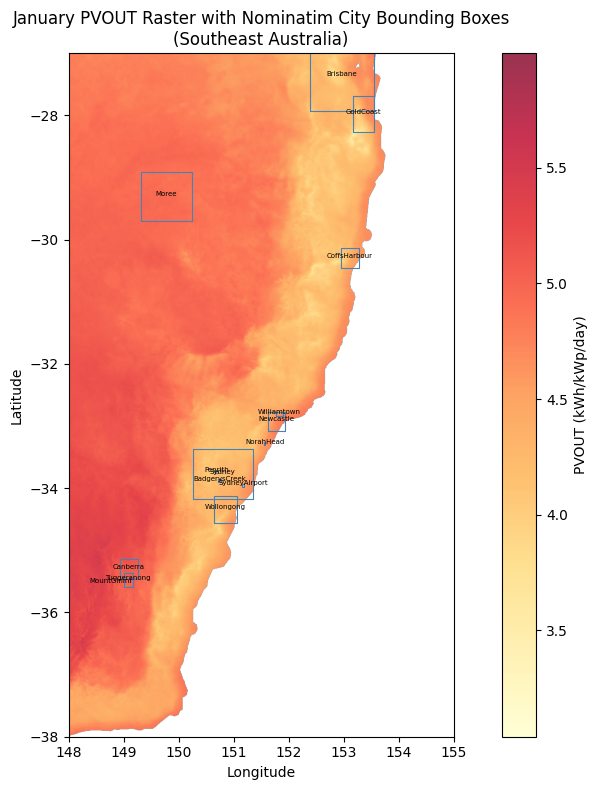

In [8]:
import geopandas as gpd

# Bbox overlay on January PVOUT raster
with rasterio.open(MONTHLY_PVOUT_DIR / "PVOUT_01.tif") as src:
    jan_data = src.read(1)
    jan_data = np.where(jan_data == src.nodata, np.nan, jan_data)

bbox_gdf = gpd.GeoDataFrame(
    [{"city": city, "geometry": geom} for city, geom in city_bboxes.items()],
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(
    jan_data, cmap="YlOrRd", extent=[112, 160, -44, -9], aspect="auto", alpha=0.8
)
plt.colorbar(img, ax=ax, label="PVOUT (kWh/kWp/day)")
bbox_gdf.boundary.plot(ax=ax, color="steelblue", linewidth=0.8)
for _, row in bbox_gdf.iterrows():
    c = row.geometry.centroid
    ax.annotate(row["city"], (c.x, c.y), fontsize=5, ha="center")
ax.set_title(
    "January PVOUT Raster with Nominatim City Bounding Boxes\n(Southeast Australia)"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(148, 155)
ax.set_ylim(-38, -27)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Map monthly PVOUT onto each weather row by city + month as the regression target. Drop `Date`, `Location`, and any date-derived columns before training — seasonality is already captured in the monthly target.

In [ ]:
# Cell 14 - Feature Engineering
CAT_COLS = ["WindGustDir", "WindDir9am", "WindDir3pm", "RainToday"]

df_train["Month"] = df_train["Date"].dt.month
df_holdout["Month"] = df_holdout["Date"].dt.month


def mode_agg(x):
    m = x.mode()
    return m[0] if not m.empty else np.nan


exclude = ["Location", "Month", "Date"]
num_cols = [c for c in df_train.columns if c not in CAT_COLS + exclude]
num_agg = {col: "mean" for col in num_cols}
cat_agg = {col: mode_agg for col in CAT_COLS}

# --- Aggregate train to per city per month ---
df_train = (
    df_train.groupby(["Location", "Month"]).agg({**num_agg, **cat_agg}).reset_index()
)
df_train["PVOUT"] = df_train.apply(
    lambda r: city_pvout_monthly.get(r["Location"], {}).get(r["Month"]), axis=1
)
df_train = df_train.dropna(subset=["PVOUT"]).drop(columns=["Location", "Month"])

# --- Aggregate holdout to per city per month for honest evaluation ---
df_holdout = (
    df_holdout.groupby(["Location", "Month"]).agg({**num_agg, **cat_agg}).reset_index()
)
df_holdout["PVOUT"] = df_holdout.apply(
    lambda r: city_pvout_monthly.get(r["Location"], {}).get(r["Month"]), axis=1
)
df_holdout = df_holdout.dropna(subset=["PVOUT"]).drop(columns=["Location", "Month"])

print(
    f"Train shape   : {df_train.shape} | PVOUT range: {df_train['PVOUT'].min():.2f} – {df_train['PVOUT'].max():.2f}"
)
print(
    f"Holdout shape : {df_holdout.shape} | PVOUT range: {df_holdout['PVOUT'].min():.2f} – {df_holdout['PVOUT'].max():.2f}"
)
print(f"\nPVOUT distribution:")
print(df_train["PVOUT"].describe().round(3))

Train shape   : (528, 21) | PVOUT range: 2.23 – 5.77
Holdout shape : (528, 21) | PVOUT range: 2.23 – 5.77

PVOUT distribution:
count    528.000
mean       4.296
std        0.797
min        2.232
25%        3.861
50%        4.391
75%        4.913
max        5.774
Name: PVOUT, dtype: float64


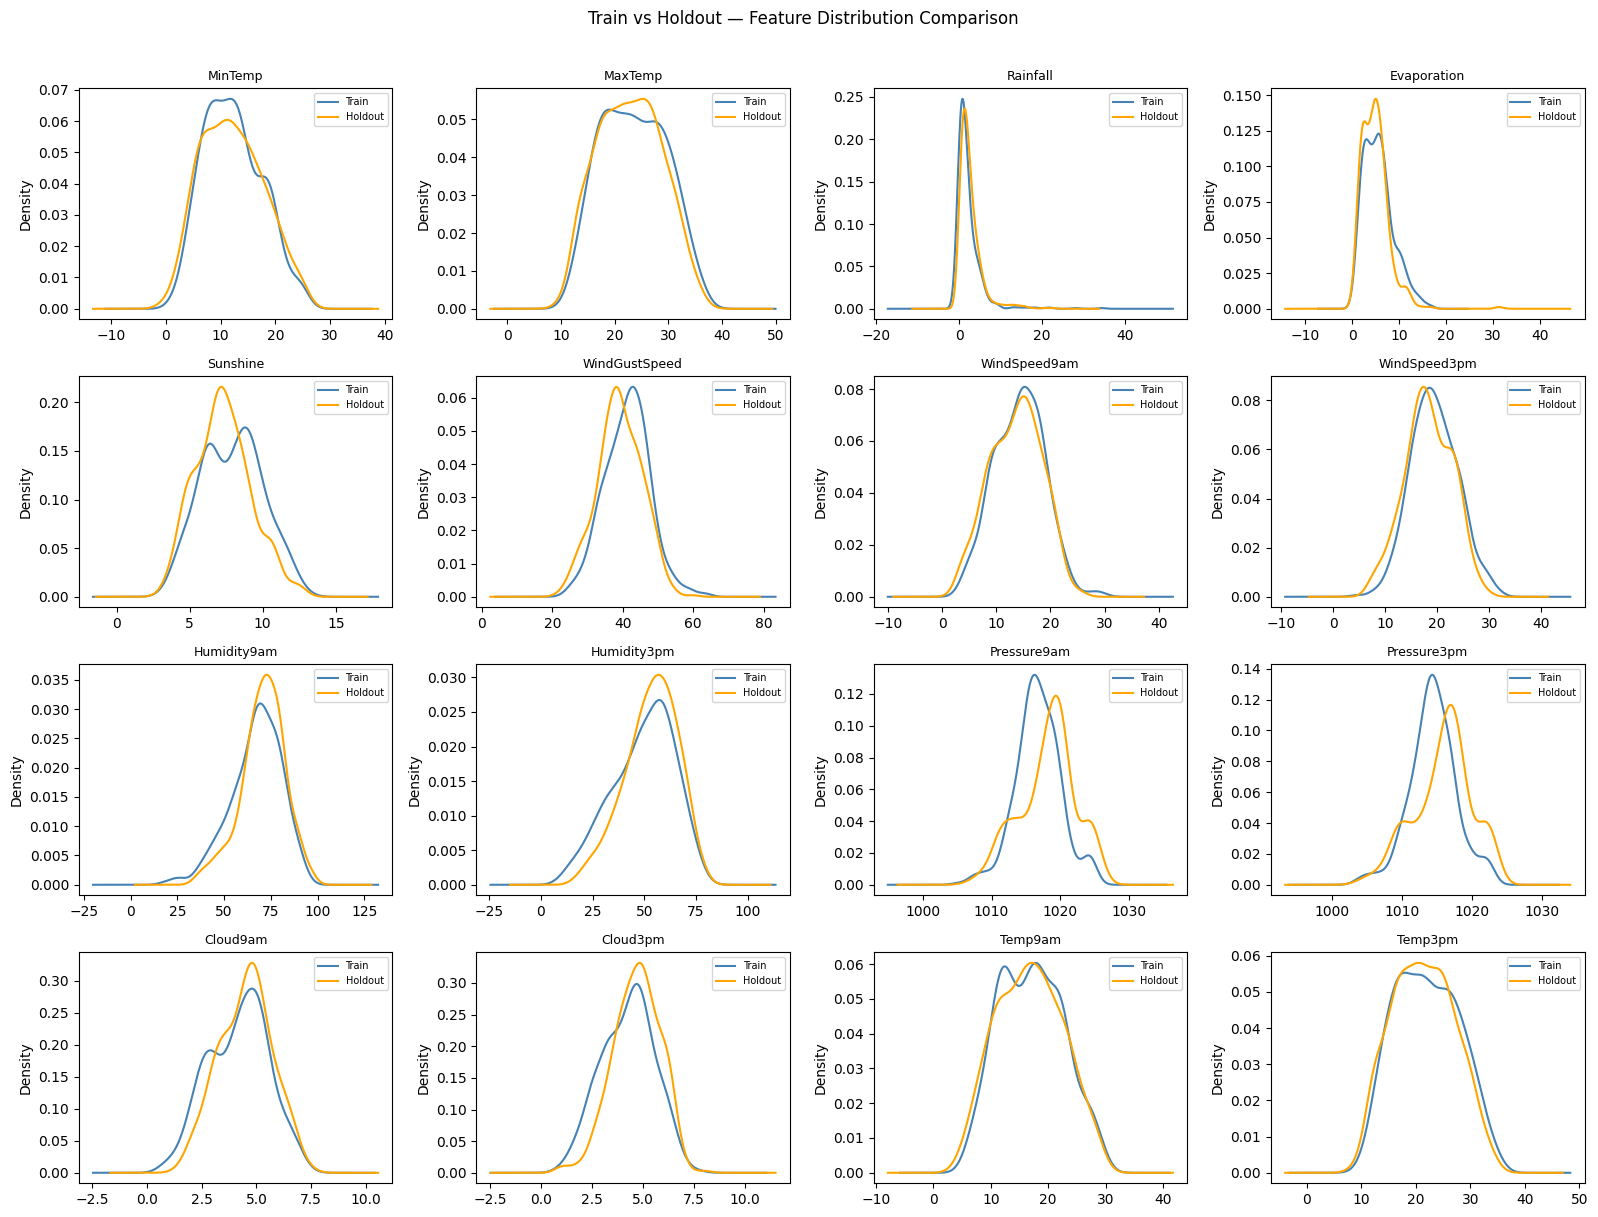

In [17]:
import math

numeric_cols = [c for c in df_train.columns if c not in CAT_COLS + ["PVOUT"]]
n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    df_train[col].dropna().plot.kde(ax=ax, label="Train", color="steelblue")
    df_holdout[col].dropna().plot.kde(ax=ax, label="Holdout", color="orange")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.legend(fontsize=7)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Train vs Holdout — Feature Distribution Comparison", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

FEATURE_COLS = [c for c in df_train.columns if c != "PVOUT"]

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([df_train[col], df_holdout[col]]).astype(str)
    le.fit(combined)
    df_train[col] = le.transform(df_train[col].astype(str))
    df_holdout[col] = le.transform(df_holdout[col].astype(str))
    encoders[col] = le

X_train = df_train[FEATURE_COLS]
y_train = df_train["PVOUT"]
X_test = df_holdout[FEATURE_COLS]
y_test = df_holdout["PVOUT"]

print(f"X_train  : {X_train.shape}")
print(f"X_test   : {X_test.shape}")
print(f"Features : {FEATURE_COLS}")

X_train  : (528, 20)
X_test   : (528, 20)
Features : ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


## 6. Model Training — Baseline XGBoost

Train an initial XGBoost regressor with sensible defaults to establish a performance baseline before tuning.

In [21]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nRMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

[0]	validation_0-rmse:0.77089
[100]	validation_0-rmse:0.43320
[200]	validation_0-rmse:0.42994
[300]	validation_0-rmse:0.42966
[400]	validation_0-rmse:0.42955
[499]	validation_0-rmse:0.42951

RMSE : 0.4295
MAE  : 0.3309
R²   : 0.7091


## 7. Hyperparameter Tuning with Optuna

100 trials of Bayesian optimisation (TPESampler) over `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, and `min_child_weight`.

In [22]:
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": 42,
        "n_jobs": -1,
    }
    m = xgb.XGBRegressor(**params)
    m.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    return r2_score(y_test, m.predict(X_test))


study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Best R²     : {study.best_value:.4f}")
print(f"Best params : {study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]

Best R²     : 0.7261
Best params : {'n_estimators': 895, 'max_depth': 6, 'learning_rate': 0.028927620425425814, 'subsample': 0.6259827530068227, 'colsample_bytree': 0.8338266718531757, 'min_child_weight': 2}


In [23]:
best_model = xgb.XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

y_pred_tuned = best_model.predict(X_test)
rmse_tuned = mean_squared_error(y_test, y_pred_tuned) ** 0.5
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"           Baseline → Tuned")
print(f"RMSE : {rmse:.4f}   → {rmse_tuned:.4f}")
print(f"MAE  : {mae:.4f}   → {mae_tuned:.4f}")
print(f"R²   : {r2:.4f}   → {r2_tuned:.4f}")

           Baseline → Tuned
RMSE : 0.4295   → 0.4168
MAE  : 0.3309   → 0.3204
R²   : 0.7091   → 0.7261


## 8. Model Evaluation

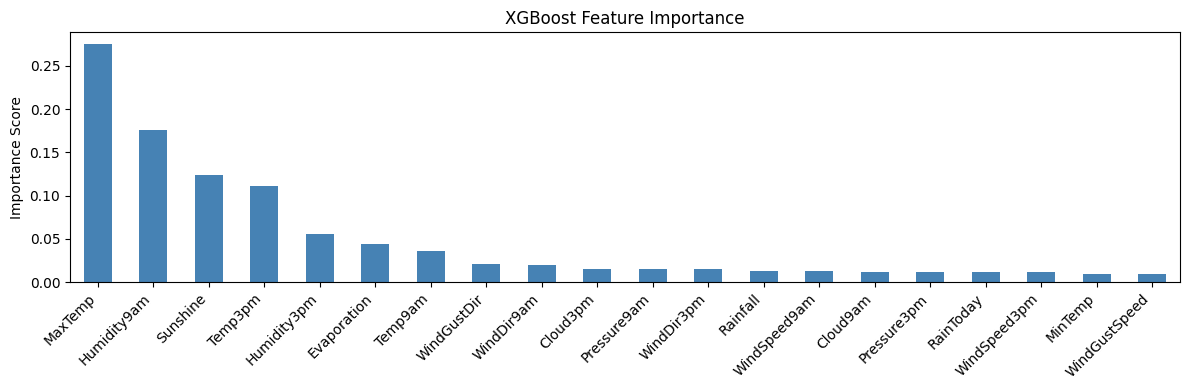

MaxTemp          0.2750
Humidity9am      0.1754
Sunshine         0.1242
Temp3pm          0.1110
Humidity3pm      0.0561
Evaporation      0.0437
Temp9am          0.0363
WindGustDir      0.0213
WindDir9am       0.0200
Cloud3pm         0.0157
Pressure9am      0.0154
WindDir3pm       0.0152
Rainfall         0.0135
WindSpeed9am     0.0127
Cloud9am         0.0119
Pressure3pm      0.0116
RainToday        0.0113
WindSpeed3pm     0.0113
MinTemp          0.0094
WindGustSpeed    0.0089
dtype: float32


In [24]:
importance = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(
    ascending=False
)

importance.plot(kind="bar", figsize=(12, 4), color="steelblue")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(importance.round(4))

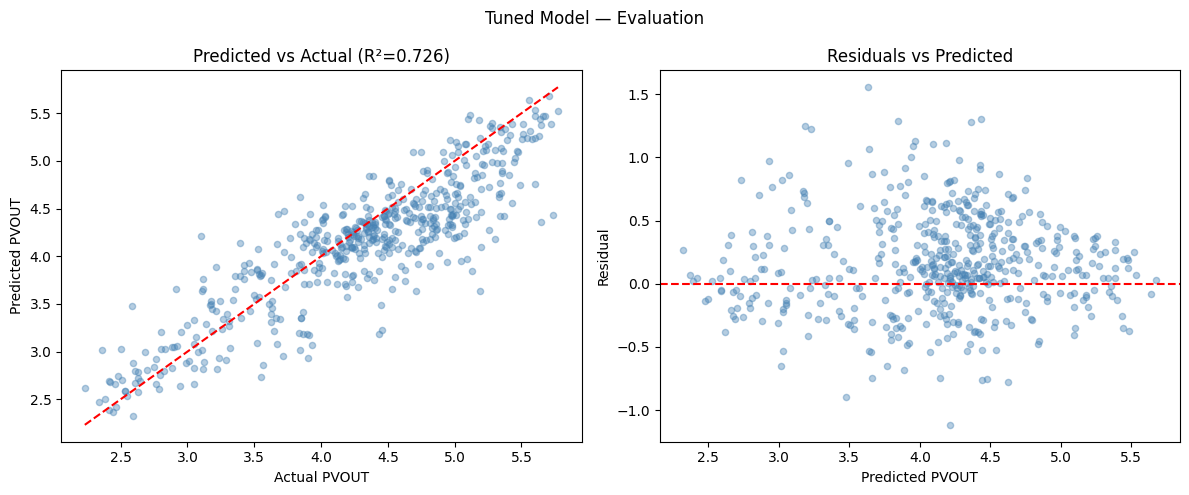

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_tuned, alpha=0.4, s=20, color="steelblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_xlabel("Actual PVOUT")
axes[0].set_ylabel("Predicted PVOUT")
axes[0].set_title(f"Predicted vs Actual (R²={r2_tuned:.3f})")

# Residuals vs Predicted
residuals = y_test - y_pred_tuned
axes[1].scatter(y_pred_tuned, residuals, alpha=0.4, s=20, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted PVOUT")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

plt.suptitle("Tuned Model — Evaluation", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Save & Verify Artifacts

Persist all artifacts needed by the production agent to `data/processed/`:

| File | Contents |
|---|---|
| `xgb_model.json` | Tuned XGBoost model |
| `encoders.pkl` | LabelEncoder per categorical column |
| `feature_cols.pkl` | Ordered feature column list |
| `holdout_weather.csv` | 2010 holdout rows (historical fallback for agent) |

Reload and re-score to confirm round-trip integrity.

In [27]:
import joblib

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(exist_ok=True)

best_model.save_model(PROCESSED_DIR / "xgb_model.json")
joblib.dump(encoders, PROCESSED_DIR / "encoders.pkl")
joblib.dump(FEATURE_COLS, PROCESSED_DIR / "feature_cols.pkl")
df_holdout_raw.to_csv(PROCESSED_DIR / "holdout_weather.csv", index=False)

print("Saved: xgb_model.json, encoders.pkl, feature_cols.pkl, holdout_weather.csv")

Saved: xgb_model.json, encoders.pkl, feature_cols.pkl, holdout_weather.csv


In [28]:
model_loaded = xgb.XGBRegressor()
model_loaded.load_model(PROCESSED_DIR / "xgb_model.json")
encoders_loaded = joblib.load(PROCESSED_DIR / "encoders.pkl")
feature_cols_loaded = joblib.load(PROCESSED_DIR / "feature_cols.pkl")

y_pred_reload = model_loaded.predict(X_test[feature_cols_loaded])
r2_reload = r2_score(y_test, y_pred_reload)

print(f"Model reload R²   : {r2_reload:.4f}")
print(f"Features          : {len(feature_cols_loaded)}")

Model reload R²   : 0.7261
Features          : 20
